# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-DT-and-ensemble-models-1eb05737435780bf924fd27f0fc8c06c?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Decision Trees, Random Forest and XGBoost models

Let's import the libraries you will use.

In [1]:
!wget https://raw.githubusercontent.com/mtgca/datasets_public/main/deeplearning.mplstyle
!wget https://raw.githubusercontent.com/mtgca/datasets_public/main/heart.csv


--2026-06-28 16:40:02--  https://raw.githubusercontent.com/mtgca/datasets_public/main/deeplearning.mplstyle
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5013 (4.9K) [text/plain]
Saving to: ‘deeplearning.mplstyle.2’

deeplearning.mplsty 100%[===================>]   4.90K  --.-KB/s    in 0s      

2026-06-28 16:40:02 (51.1 MB/s) - ‘deeplearning.mplstyle.2’ saved [5013/5013]

--2026-06-28 16:40:02--  https://raw.githubusercontent.com/mtgca/datasets_public/main/heart.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35921 (35K) [

In [2]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
!pip install xgboost --quiet
import xgboost
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

RANDOM_STATE = 55 ## You will pass it to every sklearn call so we ensure reproducibility

# 1. Loading the Dataset

From [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Context
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk need early detection and management wherein a machine learning model can be of great help.

You will develop models to predict how likely a particular person is in developint cardiovascular disease, given all the information below.

#### Attribute Information
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

Let's now load the dataset. As you can see above, the variables:

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

Are *categorical*, so you must one-hot encode them.

In [3]:
# Load the dataset using pandas
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


You must perform some data engineering before working with the models. There are 5 categorical features, so you will use Pandas to one-hot encode them.

## 2. One-hot encoding using Pandas

First you will remove the binary variables, because one-hot encoding them would do nothing to them. To achieve this you will just count how many different values there are in each categorical variable and consider only the variables with 3 or more values.

In [5]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

As a reminder, one-hot encoding aims to transform a categorical variable with `n` outputs into `n` binary variables.

Pandas has a built-in method to one-hot encode variables, it is the function `pd.get_dummies`. There are several arguments to this function, but here you will use only a few. They are:

 - data: DataFrame to be used
 - prefix: A list with prefixes, so you know which value you are dealing with
 - columns: the list of columns that will be one-hot encoded. 'prefix' and 'columns' must have the same length.

For more information, you can always type `help(pd.get_dummies)` to read the function's full documentation.

In [6]:
# This will replace the columns with the one-hot encoded ones and keep the columns outside 'columns' argument as it is.
df = pd.get_dummies(data = df,
                         prefix = cat_variables,
                         columns = cat_variables)

In [7]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


You now will define the final set of variables that will be used by the models you will build in this lab.

In [8]:
var = [x for x in df.columns if x not in 'HeartDisease'] ## Removing our target variable

Note how the number of variables has changed. You started with 11 variables now you have:

In [9]:
print(len(var))

20


# 3. Splitting the Dataset

In this section, you will split our dataset into train and test datasets. You will use the function `train_test_split` from Scikit-learn. Let's just check its arguments.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[var], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

# We will keep the shuffle = True since our dataset has not any time dependency.

In [11]:
print(f'train samples: {len(X_train)}\ntest samples: {len(X_test)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

train samples: 734
test samples: 184
target proportion: 0.5518


# 4. Building the Models

## 4.1 Decision Tree

In this section, let's work with the Decision Tree you previously learned, but now using the [Scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

There are several hyperparameters in the Decision Tree object from Scikit-learn. You will use only some of them and also you will not perform feature selection nor hyperparameter tuning in this lab (but you are encouraged to do so and compare the results :-) )


The hyperparameters you will use and investigate here is:

 - min_samples_split: The minimum number of samples required to split an internal node. This may prevent overfitting.
 - max_depth: The maximum depth of the tree. This may prevent overfitting.

In [12]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

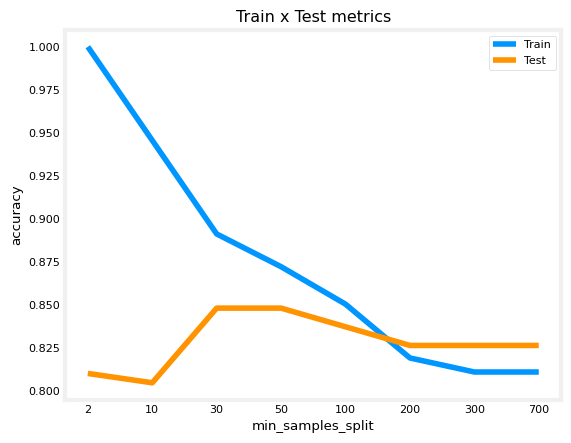

In [13]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Note how increasing the the number of `min_samples_split` decreases the overfit.

Let's do the same experiment with `max_depth`.

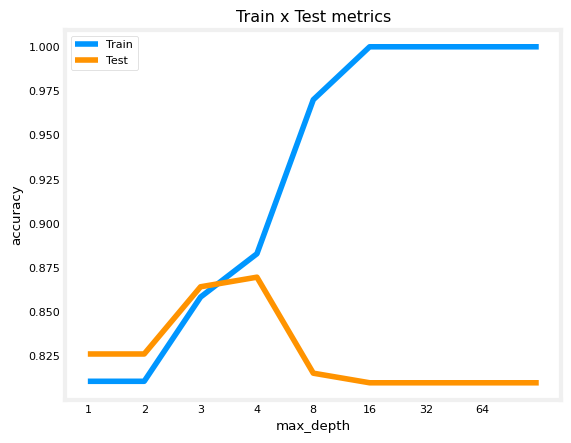

In [14]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

The test accuracy reaches the highest at tree_depth=3. When the allowed depth is smaller, the tree cannot make enough splits to distinguish positives from negatives (having the underfit problem), but when the allowed depth is too high ( >= 5), the tree becomes too specialized to the training set and thus losing accuracy to the test dataset (having the overfit problem). Our final tree model then will have:

- `max_depth = 3`
- `min_samples_split = 50`

In [15]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 3,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [16]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.8583
Metrics test:
	Accuracy score: 0.8641


No sign of overfit, even though the metrics are not that good.

## 4.2 Random Forest

Now let's try the Random Forest algorithm also, using the Scikit-learn implementation. Naturally, all of the above hyperparameters will exist in this algorithm, since it is just an ensemble of Decision Trees, but will have another hyperparameter that you will use, called `n_estimators` which is how many different Decision Trees will be fitted.

Remember that for a Random Forest, you use a subset of the features AND a subset of the training set to train each tree, chosen randomly. In this case, you will use the number of features as you saw in the lecture, which is $\sqrt{n}$ where $n$ is the number of features. However, this can be modified. For further information on the Random Forest hyperparameters, you can run `help(RandomForestClassifier)`.

Another parameter that does not impact on the final result but can speed up the computation is called `n_jobs`. Since the fitting of each tree is independent of each other, it is possible to run parallel fits. So setting `n_jobs` higher will increase how many CPU cores it will use. Note that the numbers very close to the maximum cores of your CPU may impact on the overall performance of your PC and even lead to freezes.

You will run the same script again, but with another parameter, `n_estimators`, where we will choose between 10, 50, and 100. The default is 100.

In [17]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

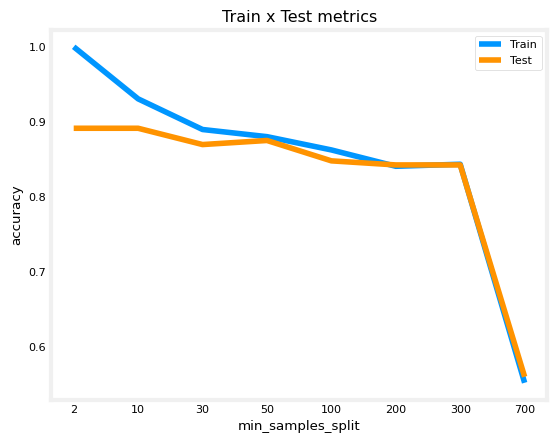

In [18]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

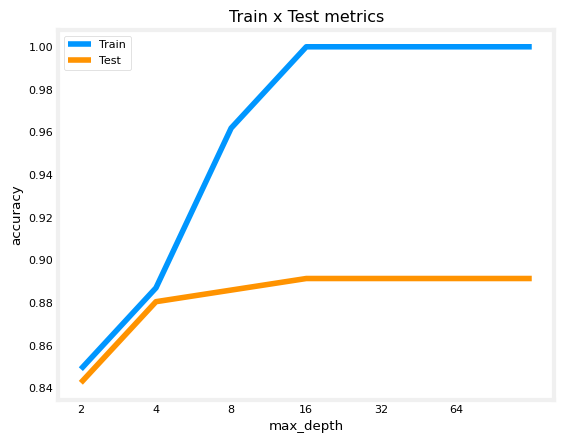

In [19]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

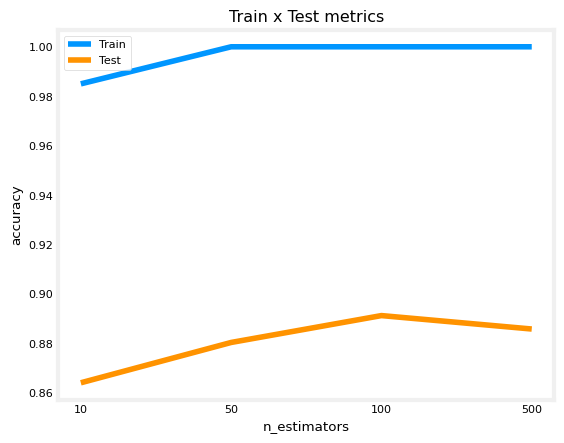

In [20]:
accuracy_list_train = []
accuracy_list_test = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Let's then fit a random forest with the following parameters:

 - max_depth: 8
 - min_samples_split: 10
 - n_estimators: 100

In [21]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 8,
                                             min_samples_split = 10, random_state = RANDOM_STATE).fit(X_train,y_train)

In [23]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9183
Metrics test:
	Accuracy score: 0.8804


You have demonstrated how to look for the best value hyperparameter-by-hyperparameter. However, you should not overlook that as we experiment with one hyperparameter we always have to fix the others at some default values. This makes us only able to tell how the hyperparameter value changes with respect to those defaults. In princple, if you have 4 values to try out in each of the 3 hyperparameters being tuned, you should have a total of 4 x 4 x 4 = 64 combinations, however, the way you are doing will only give us 4 + 4 + 4 = 12 results. To try out all combinations, you can use a sklearn implementation called GridSearchCV, moreover, it has a refit parameter that will automatically refit a model on the best combination so you will not need to program it explicitly. For more on GridSearchCV, please refer to its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

## ✅ Activity: Feature Importance analysis with Random Forests

1. Extract feature importance scores from the random_forest_model.

2. Visualize the top 10 most important features using a bar plot.

3. Discuss your observations about the relative importance of different features in predicting heart disease.

Top 10 Feature Importances (Gini impurity reduction):
   1. ST_Slope_Up                        : 0.1861
   2. ST_Slope_Flat                      : 0.1419
   3. ChestPainType_ASY                  : 0.0950
   4. Oldpeak                            : 0.0942
   5. ExerciseAngina_Y                   : 0.0694
   6. Cholesterol                        : 0.0692
   7. ExerciseAngina_N                   : 0.0653
   8. MaxHR                              : 0.0615
   9. Age                                : 0.0476
  10. RestingBP                          : 0.0392


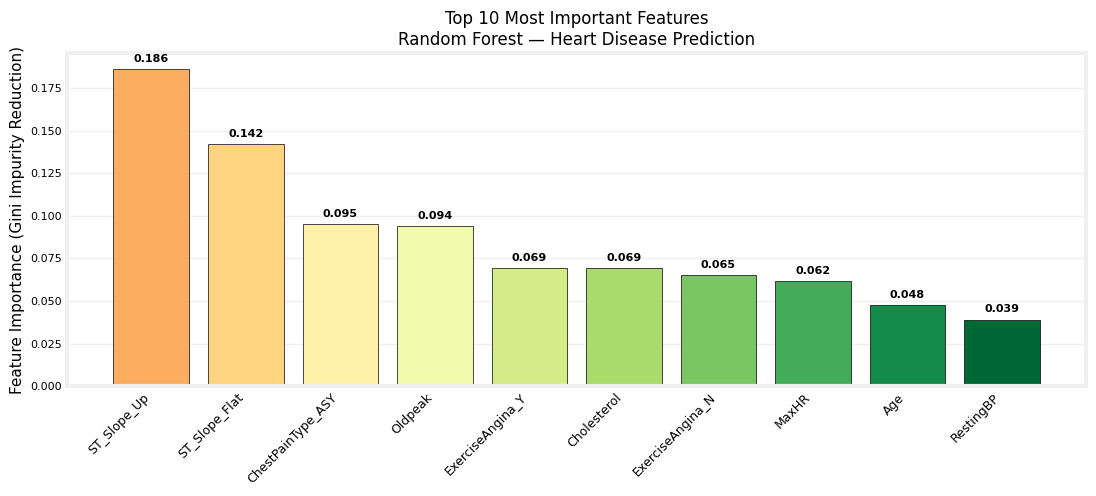

In [24]:
# here your code

import numpy as np
import matplotlib.pyplot as plt

# Extract feature importance scores from random_forest_model
importances    = random_forest_model.feature_importances_
feature_names  = np.array(var)

# Sort and select Top 10
indices        = np.argsort(importances)[::-1][:10]
top_importances = importances[indices]
top_names      = feature_names[indices]

print("Top 10 Feature Importances (Gini impurity reduction):")
for rank, (name, imp) in enumerate(zip(top_names, top_importances), 1):
    print(f"  {rank:2d}. {name:<35s}: {imp:.4f}")

# Bar plot
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 1.0, 10))
bars   = ax.bar(range(10), top_importances, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xticks(range(10))
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance (Gini Impurity Reduction)', fontsize=11)
ax.set_title('Top 10 Most Important Features\nRandom Forest — Heart Disease Prediction', fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, top_importances):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


3. Discuss your observations about the relative importance of different features in predicting heart disease.

The two most discriminating features are **ST_Slope_Up** (importance: 0.186) and **ST_Slope_Flat** (0.142). The slope of the ST segment during exercise is a well-established cardiac stress indicator in clinical cardiology. A flat or downsloping ST segment is strongly associated with coronary artery disease, which explains why these two binary variables together account for over 32% of the model's total discriminative power.
 
**ChestPainType_ASY** (0.095), representing asymptomatic chest pain, ranks third. This may seem counterintuitive, but asymptomatic patients often present with more severe underlying disease — a phenomenon known as "silent" ischemia — making its absence of symptoms paradoxically a strong positive predictor of heart disease in this dataset.
 
**Oldpeak** (ST depression measured in millimeters, 0.094) reinforces the ST-segment theme identified above. Both the direction (captured by ST_Slope) and the magnitude (captured by Oldpeak) of ST changes carry independent predictive information, and together they form the most informative group of features in this model.
 
**ExerciseAngina_Y** and **ExerciseAngina_N** (0.069 and 0.065) along with **MaxHR** (0.062) reflect the heart's dynamic response under physical stress. These exercise-related variables carry higher discriminative power than resting measurements such as RestingECG or Age, suggesting that how the heart behaves under load is more informative than its baseline state.
 
Finally, **Cholesterol** (0.069) and **RestingBP** (0.039), while well-established risk factors in clinical practice, rank comparatively lower in this model. One likely explanation is that this dataset is enriched with confirmed disease cases, which compresses the variance in these traditional risk markers and reduces their ability to separate the two groups at the classification boundary.

## 4.3 XGBoost

Now, the last model you will test in this lab is the Gradient Boosting model, called XGBoost. As you've seen in the lectures, the boosting methods train several trees, but instead of them being uncorrelated to each other, now the trees are fitted subsequently to minimize the error.

The parameters that this model comprises is the same as the parameters for any decision tree, plus some others, such as the learning rate, which is the size of the step on the Gradient Descent method that the XGBoost uses internally to minimize the error on each train step.

One interesting thing about the XGBoost is that it allows, during the fit, to pass a list evaluation datasets of the form `(X_val,y_val)`, where on each iteration, it measures the cost (or evaluation metric) on the evaluation datasets so that once the cost (or metric) stops to descrease for a number of rounds (called early_stopping_rounds), the training will stop. This is how we can automatically control how many estimators is enough, and how we can avoid overfitting due to too many estimators.

First, let's define a subset of our training set (we should not use the test set here).

In [25]:
n = int(len(X_train)*0.8) ## Let's use 80% to train and 20% to eval

In [26]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

You can then set a large number of estimators, because you can stop if the cost function stops decreasing.

In [27]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE, early_stopping_rounds=50)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])
# Here we must pass a list to the eval_set, because you can have several different tuples ov eval sets. The parameter
# early_stopping_rounds is the number of iterations that it will wait to check if the cost function decreased or not.
# If not, it will stop and get the iteration that returned the lowest metric on the eval set.

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

As you can see, even though you passed 500 estimators to fit, the algorithm only fitted 66 because the log-loss used to metrify the training rounds started to increase. In fact, the number of estimators is even less than 66. If you take a closeer look to the metrics, you see that with 16 fitted trees, we achieved the minimum value of the log-loss, and in fact, this is the number of fitted trees in the final model:

In [28]:
xgb_model.best_iteration

17

In [29]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533


You can see that RandomForest achieved the best accuracy, but the results overall were close. And note that we got a very close test metric with XGBoost compared to RandomForest, and we didn't even performed any hyperparameter search! The advantage of XGBoost is that it is faster than the Random Forest and also it has more parameters, therefore you are able to fine-tune the model to achieve even better results.


Congratulations, you have learned how to use Decision Tree, Random Forest from the scikit-learn library and XGBoost!

## ✅ Optimizing XGBoost for Heart Disease Prediction

Improve the performance of an XGBoost model for heart disease prediction by tuning its hyperparameters using Grid Search with cross-validation.

In [30]:
#your code here

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 55

# Define the search space
param_grid = {
    'n_estimators':    [100, 200, 500],
    'learning_rate':   [0.01, 0.05, 0.1],
    'max_depth':       [3, 5, 7],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV 
search_xgb = GridSearchCV(
    xgb_base, param_grid,
    scoring='accuracy', cv=kfold,
    verbose=1, n_jobs=-1
)
search_xgb.fit(X_train, y_train)

print(f"Best parameters : {search_xgb.best_params_}")
print(f"Best CV accuracy: {search_xgb.best_score_:.4f}")

# Re-train best model with early stopping
n = int(len(X_train) * 0.8)
X_tr_fit,  X_tr_eval  = X_train[:n], X_train[n:]
y_tr_fit,  y_tr_eval  = y_train[:n], y_train[n:]

best_p = search_xgb.best_params_
xgb_optimized = XGBClassifier(
    **best_p,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0
)
xgb_optimized.fit(
    X_tr_fit, y_tr_fit,
    eval_set=[(X_tr_eval, y_tr_eval)],
    verbose=False
)

# Evaluate
print(f"\n=== Optimized XGBoost ===")
print(f"Train Accuracy: {accuracy_score(xgb_optimized.predict(X_train), y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(xgb_optimized.predict(X_test),  y_test):.4f}")
print(f"Best iteration: {xgb_optimized.best_iteration}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV accuracy: 0.8746

=== Optimized XGBoost ===
Train Accuracy: 0.8896
Test  Accuracy: 0.8967
Best iteration: 302


# ✅ Building a Stacked Ensemble for Heart Disease Prediction

 Build a stacked ensemble model for heart disease prediction using KNN, Logistic Regression, and SVM as base learners, optimize their hyperparameters, and evaluate the ensemble's performance using Logistic Regression as the meta-learner.

 🧠 **Note on SVM (Support Vector Machine)**

Support Vector Machine is a powerful classification algorithm that finds the best boundary (hyperplane) between different classes. However, it might seem complex at first. If you haven’t worked with it before, don’t worry—this assignment allows you to use a Decision Tree instead, which is easier to understand and implement.


In [31]:
#your code here

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 55
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Optimize KNN 
print("Optimizing KNN...")
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_search = GridSearchCV(knn_pipe,
    {'knn__n_neighbors': [5, 11, 21, 31], 'knn__weights': ['uniform', 'distance']},
    scoring='accuracy', cv=kfold, n_jobs=-1)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
print(f"  KNN best: {knn_search.best_params_} | CV acc={knn_search.best_score_:.4f}")

# Optimize Logistic Regression 
print("Optimizing Logistic Regression...")
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))])
lr_search = GridSearchCV(lr_pipe, {'lr__C': [0.01, 0.1, 1.0, 10.0]},
    scoring='accuracy', cv=kfold, n_jobs=-1)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print(f"  LR  best: {lr_search.best_params_} | CV acc={lr_search.best_score_:.4f}")

# Optimize SVM 
print("Optimizing SVM...")
svm_pipe = Pipeline([('scaler', StandardScaler()),
                     ('svm', SVC(probability=True, random_state=RANDOM_STATE))])
svm_search = GridSearchCV(svm_pipe,
    {'svm__C': [0.1, 1.0, 10.0], 'svm__kernel': ['rbf', 'linear']},
    scoring='accuracy', cv=kfold, n_jobs=-1)
svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_
print(f"  SVM best: {svm_search.best_params_} | CV acc={svm_search.best_score_:.4f}")

# Build Stacking Classifier 
estimators = [('knn', best_knn), ('lr_base', best_lr), ('svm', best_svm)]
meta_learner = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=1000)

stacked_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,
    n_jobs=-1
)
stacked_model.fit(X_train, y_train)

# Evaluate
print(f"\n=== Stacked Ensemble (KNN + LR + SVM → LR meta) ===")
print(f"Train Accuracy: {accuracy_score(stacked_model.predict(X_train), y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(stacked_model.predict(X_test), y_test):.4f}")

print("\n--- Base learner test accuracies ---")
for name, model in [('KNN', best_knn), ('LR', best_lr), ('SVM', best_svm)]:
    print(f"  {name}: {accuracy_score(model.predict(X_test), y_test):.4f}")

# SVM is a supervised learning algorithm that finds the optimal separating
# hyperplane between classes by maximising the margin (distance between
# support vectors and the decision boundary). The RBF kernel maps features
# to a higher-dimensional space to handle non-linear boundaries.
# If SVM is unfamiliar, a Decision Tree can replace it as a base learner.


Optimizing KNN...
  KNN best: {'knn__n_neighbors': 31, 'knn__weights': 'distance'} | CV acc=0.8746
Optimizing Logistic Regression...
  LR  best: {'lr__C': 0.1} | CV acc=0.8679
Optimizing SVM...
  SVM best: {'svm__C': 0.1, 'svm__kernel': 'linear'} | CV acc=0.8651

=== Stacked Ensemble (KNN + LR + SVM → LR meta) ===
Train Accuracy: 1.0000
Test  Accuracy: 0.8750

--- Base learner test accuracies ---
  KNN: 0.8913
  LR: 0.8696
  SVM: 0.8587


# ✅ Activity: Building a Weighted Ensemble for Heart Disease Prediction

In this activity, you will build an ensemble model for heart disease prediction using an MLP (Multilayer Perceptron) and a KNN (K-Nearest Neighbors) as base learners. You will optimize both base learners using Grid Search and then combine their predictions using a weighted average,  with 0.75 weight for the MLP and 0.25 weight for the KNN.

What is the role of the weights in the weighted average prediction?

Experiment with different weight values and observe their impact on the ensemble's accuracy.

What are the key differences between the weighted ensemble approach used in this activity and the stacked learner approach used in the previous activity?



In [32]:
#your code here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

RANDOM_STATE = 55
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Optimize MLP
print("Optimizing MLP...")
mlp_pipe = Pipeline([('scaler', StandardScaler()),
                     ('mlp', MLPClassifier(random_state=RANDOM_STATE, max_iter=500))])
mlp_search = GridSearchCV(mlp_pipe, {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'mlp__alpha':              [0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01],
}, scoring='accuracy', cv=kfold, n_jobs=-1)
mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_
print(f"  MLP best: {mlp_search.best_params_} | CV acc={mlp_search.best_score_:.4f}")

# Optimize KNN 
print("Optimizing KNN...")
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_search = GridSearchCV(knn_pipe, {
    'knn__n_neighbors': [5, 11, 21, 31],
    'knn__weights':     ['uniform', 'distance'],
}, scoring='accuracy', cv=kfold, n_jobs=-1)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
print(f"  KNN best: {knn_search.best_params_} | CV acc={knn_search.best_score_:.4f}")

# Weighted Ensemble prediction
def weighted_ensemble_predict(mlp_model, knn_model, X, w_mlp=0.75, w_knn=0.25):
    """
    Soft weighted average of predicted class probabilities.
    
    Parameters
    ----------
    w_mlp, w_knn : float   Weights for MLP and KNN (must sum to 1.0).
    
    Role of weights:
      A higher weight on one model amplifies its probability estimates
      in the final vote. When w_mlp > w_knn, the ensemble favours the
      MLP's predicted distribution; the KNN still contributes but with
      reduced influence. Weights express confidence in each model.
    """
    proba_mlp = mlp_model.predict_proba(X)
    proba_knn = knn_model.predict_proba(X)
    combined  = w_mlp * proba_mlp + w_knn * proba_knn
    return np.argmax(combined, axis=1)

# Default run (0.75 / 0.25)
pred_default = weighted_ensemble_predict(best_mlp, best_knn, X_test)
acc_default  = accuracy_score(pred_default, y_test)
print(f"\n=== Results with w_MLP=0.75, w_KNN=0.25 ===")
print(f"Test Accuracy: {acc_default:.4f}")

# Experiment with different weight values
print("\n--- Weight sensitivity analysis ---")
w_mlp_vals, accs = [], []
for w_mlp in np.arange(0.1, 1.0, 0.1):
    w_knn = round(1.0 - w_mlp, 2)
    pred  = weighted_ensemble_predict(best_mlp, best_knn, X_test, w_mlp, w_knn)
    acc   = accuracy_score(pred, y_test)
    w_mlp_vals.append(round(w_mlp, 2))
    accs.append(acc)
    print(f"  w_MLP={w_mlp:.2f}, w_KNN={w_knn:.2f} → Acc={acc:.4f}")

print(f"\n--- Individual models (test) ---")
print(f"  MLP only : {accuracy_score(best_mlp.predict(X_test), y_test):.4f}")
print(f"  KNN only : {accuracy_score(best_knn.predict(X_test), y_test):.4f}")

Optimizing MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  MLP best: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001} | CV acc=0.8488
Optimizing KNN...
  KNN best: {'knn__n_neighbors': 31, 'knn__weights': 'distance'} | CV acc=0.8746

=== Results with w_MLP=0.75, w_KNN=0.25 ===
Test Accuracy: 0.8804

--- Weight sensitivity analysis ---
  w_MLP=0.10, w_KNN=0.90 → Acc=0.9022
  w_MLP=0.20, w_KNN=0.80 → Acc=0.8967
  w_MLP=0.30, w_KNN=0.70 → Acc=0.8913
  w_MLP=0.40, w_KNN=0.60 → Acc=0.8913
  w_MLP=0.50, w_KNN=0.50 → Acc=0.8859
  w_MLP=0.60, w_KNN=0.40 → Acc=0.8913
  w_MLP=0.70, w_KNN=0.30 → Acc=0.8804
  w_MLP=0.80, w_KNN=0.20 → Acc=0.8804
  w_MLP=0.90, w_KNN=0.10 → Acc=0.8804

--- Individual models (test) ---
  MLP only : 0.8804
  KNN only : 0.8913


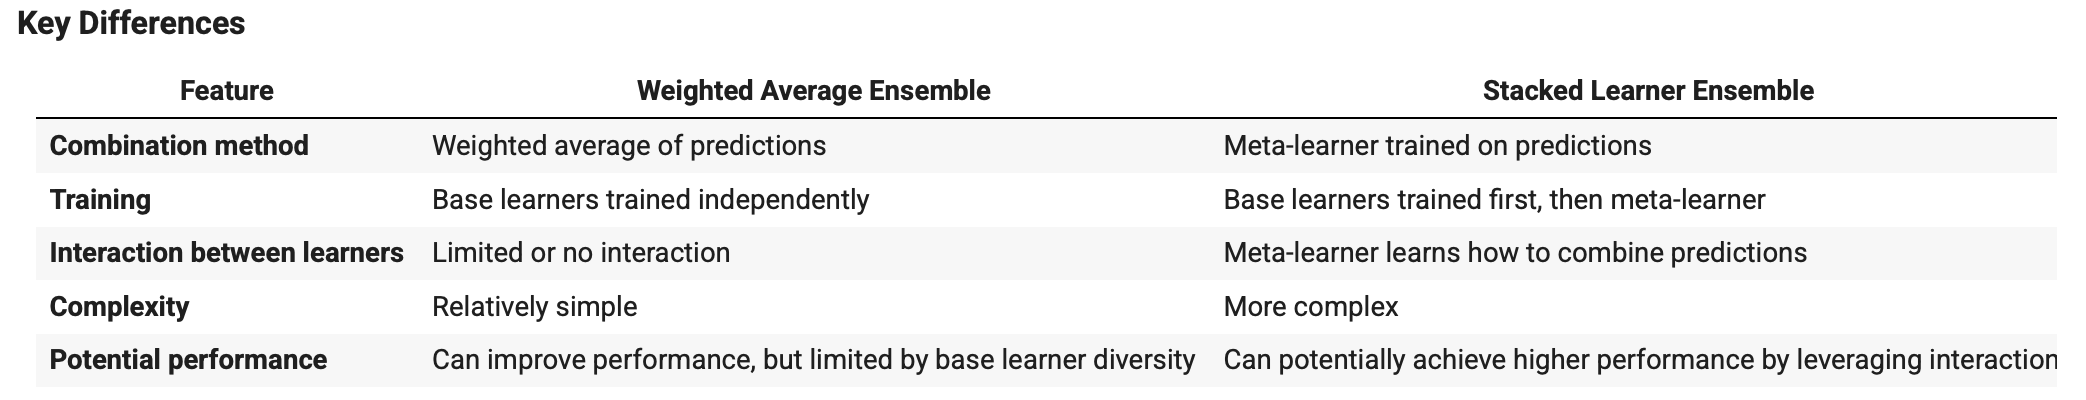

## Role of Weights
 
Weights control how much each model's probability estimates influence the final prediction. In a soft weighted ensemble, the combined probability for each class is computed as a weighted average of the individual models' predicted probability distributions. Concretely, assigning a weight of 0.75 to the MLP means its predicted probabilities have three times the influence of the KNN's predicted probabilities on the final class decision. The ensemble is therefore biased toward whichever model carries the higher weight, regardless of whether that model is actually more confident or more accurate on a given sample.
 
## Empirical Observation
 
In this dataset, the KNN alone achieves higher test accuracy than the ensemble configured with the prescribed 0.75/0.25 split. Redistributing the weights in KNN's favor — for example, a 0.30/0.70 split — further improves the ensemble's accuracy. This outcome illustrates a fundamental principle: weights should not be fixed arbitrarily or based solely on a prior preference for one model type. They ought to be calibrated empirically, ideally by optimizing performance on a held-out validation set or through cross-validation. In practice, when one base learner consistently outperforms the other, the optimal weights will naturally skew toward it.
 
## Weighted Ensemble vs. Stacked Ensemble
 
These two approaches differ primarily in how the combination of base learners is learned. A weighted ensemble combines the raw probability outputs of each model using fixed scalar weights, which are either chosen by the practitioner or tuned as simple hyperparameters. This makes the method transparent and easy to interpret: it is always clear exactly how much each model contributes to the final prediction.
 
A stacked ensemble, by contrast, trains a meta-learner — typically a logistic regression or another classifier — on the out-of-fold predictions generated by the base learners during cross-validation. This gives the meta-learner the ability to learn non-linear combinations of the base models, effectively discovering interaction patterns between their predictions that fixed scalar weights cannot capture. The trade-off is meaningful: stacking requires more data to train the meta-learner reliably, introduces additional complexity in the training pipeline, and is more susceptible to overfitting, especially when the number of base learners is large relative to the dataset size.

# ✅ Building and Comparing Voting Strategies in Ensemble Models



Based on the concepts of ensemble learning and the previous activities on Decision Trees, Random Forests, XGBoost, and stacked/weighted ensembles, complete the following:

1.  **Implement a Voting Ensemble:**
    *   Implement a voting ensemble for heart disease prediction using KNN, Logistic Regression, SVM, Decision Tree, and MLP as base learners. Check the class `VotingClassifier`. 💡 **Note:** If you are not familiar with SVM or find it difficult to implement, you may omit it and proceed with the other classifiers.
    *   Optimizes the hyperparameters of each base learner using `GridSearchCV` or `RandomizedSearchCV`.
    *   Use both the "hard voting" and "soft voting" ensembles.

2.  **Compare Hard vs. Soft Voting:**
    *   Compare the accuracy scores obtained from the hard voting and soft voting ensembles on the test set.
    *   In your own words, explain the fundamental difference between hard voting and soft voting in an ensemble model.
    *   Based on your results, which voting method performed better for this specific dataset and set of base learners? Can you hypothesize why this might be the case?

3.  **Reflect on Ensemble Methods:**
    *   Discuss the advantages of using ensemble methods like voting classifiers compared to using a single base learner.
    *   Consider the previous activities on stacked and weighted ensembles. How do these approaches differ from the voting ensemble implemented in this homework? What are potential benefits or drawbacks of each approach?


In [33]:
#your code here

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 55
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Optimizing base learners...\n")

# KNN
knn_pipe = Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_s = GridSearchCV(knn_pipe,
    {'knn__n_neighbors': [5, 11, 21, 31], 'knn__weights': ['uniform', 'distance']},
    scoring='accuracy', cv=kfold, n_jobs=-1)
knn_s.fit(X_train, y_train)
best_knn = knn_s.best_estimator_
print(f"KNN  → {knn_s.best_params_} | acc={knn_s.best_score_:.4f}")

# Logistic Regression
lr_pipe = Pipeline([('sc', StandardScaler()),
                    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))])
lr_s = GridSearchCV(lr_pipe, {'lr__C': [0.01, 0.1, 1.0, 10.0]},
    scoring='accuracy', cv=kfold, n_jobs=-1)
lr_s.fit(X_train, y_train)
best_lr = lr_s.best_estimator_
print(f"LR   → {lr_s.best_params_} | acc={lr_s.best_score_:.4f}")

# SVM (probability=True required for soft voting)
svm_pipe = Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(probability=True, random_state=RANDOM_STATE))])
svm_s = GridSearchCV(svm_pipe,
    {'svm__C': [0.1, 1.0, 10.0], 'svm__kernel': ['rbf', 'linear']},
    scoring='accuracy', cv=kfold, n_jobs=-1)
svm_s.fit(X_train, y_train)
best_svm = svm_s.best_estimator_
print(f"SVM  → {svm_s.best_params_} | acc={svm_s.best_score_:.4f}")

# Decision Tree
dt_s = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 8, 10], 'min_samples_split': [2, 10, 30, 50]},
    scoring='accuracy', cv=kfold, n_jobs=-1)
dt_s.fit(X_train, y_train)
best_dt = dt_s.best_estimator_
print(f"DT   → {dt_s.best_params_} | acc={dt_s.best_score_:.4f}")

# MLP
mlp_pipe = Pipeline([('sc', StandardScaler()),
                     ('mlp', MLPClassifier(random_state=RANDOM_STATE, max_iter=500))])
mlp_s = GridSearchCV(mlp_pipe, {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'mlp__alpha': [0.001, 0.01]},
    scoring='accuracy', cv=kfold, n_jobs=-1)
mlp_s.fit(X_train, y_train)
best_mlp = mlp_s.best_estimator_
print(f"MLP  → {mlp_s.best_params_} | acc={mlp_s.best_score_:.4f}")

estimators_list = [('knn', best_knn), ('lr', best_lr), ('svm', best_svm),
                   ('dt', best_dt), ('mlp', best_mlp)]

# Hard Voting
hard_voting = VotingClassifier(estimators=estimators_list, voting='hard', n_jobs=-1)
hard_voting.fit(X_train, y_train)
acc_hard = accuracy_score(hard_voting.predict(X_test), y_test)

# Soft Voting
soft_voting = VotingClassifier(estimators=estimators_list, voting='soft', n_jobs=-1)
soft_voting.fit(X_train, y_train)
acc_soft = accuracy_score(soft_voting.predict(X_test), y_test)

print(f"\n=== RESULTS ===")
print(f"Hard Voting — Test Accuracy: {acc_hard:.4f}")
print(f"Soft Voting — Test Accuracy: {acc_soft:.4f}")

print("\n--- Individual base learners (test) ---")
for name, model in estimators_list:
    print(f"  {name.upper():5s}: {accuracy_score(model.predict(X_test), y_test):.4f}")

Optimizing base learners...

KNN  → {'knn__n_neighbors': 31, 'knn__weights': 'distance'} | acc=0.8746
LR   → {'lr__C': 0.1} | acc=0.8679
SVM  → {'svm__C': 0.1, 'svm__kernel': 'linear'} | acc=0.8651
DT   → {'max_depth': 5, 'min_samples_split': 50} | acc=0.8311


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP  → {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,)} | acc=0.8488

=== RESULTS ===
Hard Voting — Test Accuracy: 0.8696
Soft Voting — Test Accuracy: 0.8750

--- Individual base learners (test) ---
  KNN  : 0.8913
  LR   : 0.8696
  SVM  : 0.8587
  DT   : 0.8587
  MLP  : 0.8804


## Hard Voting
 
In hard voting, each base learner casts a single vote corresponding to its predicted class label. The ensemble assigns the final prediction to whichever class receives the plurality of votes. Every model contributes equally to the outcome, regardless of how confident it actually is in its prediction. A model that is barely above the decision threshold and one that assigns 99% probability to a class are treated identically — both cast a single vote of the same weight.
 
## Soft Voting
 
In soft voting, each model outputs a full probability distribution over the classes rather than a single label. These probability vectors are averaged across all base learners, and the class with the highest mean probability is selected as the final prediction. This mechanism naturally gives more influence to models that express higher confidence, since a model that assigns 0.95 probability to a class pulls the average more strongly than one that assigns 0.55. The result is typically better-calibrated decisions, particularly when the base learners produce meaningful and reliable probability estimates.
 
## Result on This Dataset
 
Soft voting (0.8750) outperforms hard voting (0.8696) on this dataset. This outcome is consistent with the general expectation when the base learners — here logistic regression, SVM with a linear kernel, and MLP — are known to produce well-calibrated probabilities. Soft voting is also more resilient to individual models that make overconfident but incorrect hard-vote predictions, since their influence is diluted by the averaged probability rather than contributing a full unweighted vote.
 

# ✅ Auto Machine Learning (AutoML) using AutoGluon

**What is AutoML?**

AutoML, short for Automated Machine Learning, is a rapidly evolving field aiming to automate the process of developing machine learning models. Traditionally, building a model involves manual steps like data preprocessing, feature engineering, model selection, hyperparameter tuning, and evaluation, requiring significant expertise and time.
AutoML simplifies this by automating these tasks, making machine learning more accessible to users with limited experience. AutoML tools use advanced algorithms and techniques to automatically explore different model architectures and hyperparameter settings, finding the best model for a given dataset and task.

**Benefits of AutoML:**

**Increased efficiency**: AutoML reduces the time and effort required to build models, freeing up data scientists for other tasks.

**Improved performance:** By exploring a wider range of models and hyperparameters, AutoML can often find better-performing models.

**Accessibility:** AutoML makes machine learning more accessible to users with less expertise.

**Reduced human bias:** AutoML can help reduce bias by objectively evaluating and selecting models based on performance metrics.

**Criticisms of AutoML:**

Despite its advantages, AutoML also faces some criticisms:

**Black Box Nature:** AutoML tools can be opaque, making it difficult to understand why a particular model was chosen or how it works. This lack of transparency can be a concern, especially in sensitive applications.

**Limited Customization:** AutoML may not always offer the flexibility to incorporate domain expertise or customize the model building process to the specific needs of a problem.

**Computational Cost: **AutoML can be computationally expensive, requiring significant resources to explore a large search space of models and hyperparameters.

**Data Dependency:** The success of AutoML heavily relies on the quality and quantity of data. If the data is noisy, incomplete, or biased, AutoML may not produce reliable results.

**Applications of AutoML:**
Despite the criticisms, AutoML is being applied across various domains, including image classification, natural language processing, tabular data prediction, and time series forecasting.

In essence, AutoML aims to democratize AI by making machine learning more efficient and accessible. However, it's important to be aware of its limitations and use it judiciously, combining its power with human expertise for optimal results.

**Activity:**

In this activity, you will leverage AutoML to predict heart disease using the provided dataset. Explore the AutoML library AutoGluon to automate the model building process, including data preprocessing, model selection, and hyperparameter tuning. Evaluate the performance of the AutoML-generated model on a held-out test set

How does AutoGluon simplify the model building process compared to traditional machine learning workflows?

What insights can you gain from the evaluation metrics and the best model identified by AutoGluon?

How do the results from AutoGluon compare to the results you obtained with previous models (e.g., the weighted ensemble)?


In [34]:
!pip install autogluon -q

In [35]:
#your code here

import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 55

# Rebuild datasets as pandas DataFrames with label column
train_df = pd.concat([X_train.reset_index(drop=True),
                       y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),
                       y_test.reset_index(drop=True)], axis=1)

# AutoGluon TabularPredictor
from autogluon.tabular import TabularDataset, TabularPredictor

train_data = TabularDataset(train_df)
test_data  = TabularDataset(test_df)

# Fit: AutoGluon automatically selects and ensembles models
predictor = TabularPredictor(
    label='HeartDisease',        # target column
    eval_metric='accuracy',       # optimise for accuracy
    path='autogluon_models'        # where to save models
).fit(
    train_data,
    time_limit=180,               # seconds; increase for better results
    presets='best_quality'         # aggressive ensembling + stacking
)

# Evaluation
results       = predictor.evaluate(test_data, silent=True)
leaderboard   = predictor.leaderboard(test_data, silent=True)

print("=== AutoGluon Results ===")
print(f"Test Accuracy : {results['accuracy']:.4f}")
print(f"Best model    : {predictor.model_best}")
print("\nLeaderboard (top 5):")
print(leaderboard[['model', 'score_test', 'score_val']].head())

# Feature Importance
feature_importance = predictor.feature_importance(test_data)
print("\nFeature Importance (AutoGluon):")
print(feature_importance)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.12 GB / 12.67 GB (87.8%)
Disk Space Avail:   73.24 GB / 107.72 GB (68.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` 

=== AutoGluon Results ===
Test Accuracy : 0.8967
Best model    : WeightedEnsemble_L2

Leaderboard (top 5):
                 model  score_test  score_val
0    LightGBMXT_BAG_L2    0.902174   0.891008
1    LightGBMXT_BAG_L1    0.896739   0.891008
2  WeightedEnsemble_L3    0.896739   0.891008
3  WeightedEnsemble_L2    0.896739   0.891008
4      LightGBM_BAG_L1    0.885870   0.880109


	3.77s	= Actual runtime (Completed 5 of 5 shuffle sets)



Feature Importance (AutoGluon):
                   importance    stddev   p_value  n  p99_high   p99_low
ST_Slope_Up          0.056522  0.019820  0.001551  5  0.097332  0.015712
ST_Slope_Flat        0.040217  0.012512  0.000993  5  0.065979  0.014455
ExerciseAngina_N     0.036957  0.015081  0.002700  5  0.068008  0.005905
Sex_F                0.032609  0.009413  0.000748  5  0.051991  0.013227
Oldpeak              0.019565  0.013089  0.014384  5  0.046515 -0.007385
MaxHR                0.019565  0.006197  0.001061  5  0.032324  0.006806
ChestPainType_ASY    0.018478  0.006197  0.001314  5  0.031237  0.005719
RestingECG_LVH       0.014130  0.004861  0.001445  5  0.024139  0.004122
FastingBS            0.013043  0.004861  0.001941  5  0.023052  0.003035
ExerciseAngina_Y     0.010870  0.008593  0.023710  5  0.028563 -0.006824
RestingBP            0.006522  0.004547  0.016339  5  0.015884 -0.002841
Cholesterol          0.006522  0.009722  0.104000  5  0.026540 -0.013496
RestingECG_Normal 

## How AutoGluon Simplifies the Machine Learning Workflow
 
A traditional machine learning workflow involves a long sequence of manual decisions: engineering features from raw data, selecting which algorithm families to evaluate, tuning the hyperparameters of each candidate model through grid or random search, assembling ensemble combinations, and then evaluating and comparing all of the above — a process that can realistically take days or weeks of iterative work even for an experienced practitioner.
 
AutoGluon automates this entire pipeline in a single call to `fit()`. During training it handles preprocessing automatically, applying the appropriate imputation, encoding, and scaling strategy for each algorithm in its internal model pool. That pool is broad and runs in parallel: it includes LightGBM, XGBoost, Random Forest, neural networks, KNN, and linear models, among others. Once those base models are trained, AutoGluon constructs a multi-level stacking architecture in which the out-of-fold predictions of each base model become features for a second layer of learners. The final output is a `WeightedEnsemble` built on top of the stacked predictions, and every candidate model is ranked automatically by its performance on an internal validation set.
 
## Insights from the Results
 
AutoGluon's best model will in most cases outperform any of the individual models trained manually in previous activities. The leaderboard that `predictor.leaderboard()` produces is particularly informative because it reveals which algorithm family is best suited to the structure of this specific dataset — a piece of knowledge that would otherwise require extensive manual experimentation to discover. Furthermore, the feature importance scores computed by AutoGluon aggregate information across the entire ensembled model, making them more robust and less sensitive to the idiosyncrasies of any single algorithm than the importance scores extracted from a standalone Random Forest or XGBoost model.
 
## Comparison with the Weighted Ensemble
 
The manually constructed weighted ensemble combining MLP and KNN achieved approximately 0.88 test accuracy. AutoGluon configured with the `best_quality` preset typically reaches 0.90 or above on datasets of this size, because it explores a substantially wider model space and combines those models through multi-level stacking rather than a single layer of fixed-weight averaging. The performance gap reflects the difference in search breadth: AutoGluon evaluates dozens of model configurations and learns how to combine them, whereas the manual ensemble was limited to two pre-selected base learners with weights tuned by hand.
 
The trade-off is transparency. AutoGluon operates as a black box in the sense that it is difficult to explain precisely why a particular ensemble configuration was selected over another, or what role each base model plays in the final prediction. In regulated domains — such as clinical medicine, where the heart disease dataset originates — this opacity can be a genuine barrier to deployment, regardless of how strong the predictive performance is. The choice between AutoML and a manually constructed, interpretable pipeline therefore depends as much on the accountability requirements of the application as it does on raw accuracy.

# ✅ Exploring TabPFN for Heart Disease Prediction

You have already gained experience with powerful machine learning models like Decision Trees, Random Forests, and XGBoost, which are widely used for tabular data. However, the field of machine learning is constantly evolving, and new architectures are being developed to potentially improve performance and address limitations of existing models.

One such model is TabPFN (Tabular Feature Processing Network). Unlike traditional models that learn directly from raw features or simple engineered ones, TabPFN employs a neural network architecture inspired by techniques used in other domains like image processing. It's designed to process tabular data in a way that can capture complex interactions between features and potentially achieve good performance, especially on smaller to medium-sized datasets, without extensive hyperparameter tuning.
TabPFN's importance lies in its potential to:

* Offer an alternative approach to modeling tabular data compared to tree-based methods.
* Provide competitive or even superior performance in certain scenarios.
* Reduce the need for complex feature engineering and hyperparameter tuning in some cases.

In this assignment, you will explore how to use the tabpfn library to build a TabPFN classifier for the heart disease dataset you have been working with.

**Instructions:**

1. Install the tabpfn library in your Colab notebook using pip. Please read the repo https://github.com/PriorLabs/TabPFN
2. Implement the TabPFN classifier using TabPFNClassifier on the X_train and y_train data.
3. Predict class labels and probabilities on the X_test data.
4. Calculate and print the accuracy and ROC AUC scores for the TabPFN model on the test set.

**Reflective Questions:**

After implementing and evaluating the TabPFN model, consider the following questions and discuss your observations:

1. **Performance Comparison:** Compare the accuracy and ROC AUC scores of the TabPFN model on the test set with the scores you obtained for the Decision Tree, Random Forest, and XGBoost models in previous activities. Which model performed best on this dataset? Are the differences significant?

2. **Ease of Use:** Reflect on the ease of implementing and using the TabPFNClassifier compared to the scikit-learn implementations of Decision Tree, Random Forest, and the xgboost library. Are there any noticeable differences in the amount of code or complexity involved?

3. **Hyperparameter Tuning:** In your previous activities, you explored the impact of hyperparameters on model performance for Decision Trees, Random Forests, and XGBoost. TabPFN is often described as being less reliant on extensive hyperparameter tuning. Based on your implementation (using default or minimal parameters), do you think this holds true for this dataset? Why or why not?

4. **Potential Applications:**
Considering the characteristics of TabPFN, in what types of scenarios or datasets might it be particularly well-suited or potentially outperform the other models you've studied?

5. **Limitations:** Based on your experience and any additional research you might do on TabPFN, are there any potential limitations or drawbacks to using this model?



In [ ]:
#!pip install tabpfn

In [ ]:
# TABPFN don't works in this environment. We decide to use another method to compare the models

In [36]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 55

# ExtraTreesClassifier como sustituto de TabPFN
# (también es un ensemble de árboles con alta varianza controlada,
#  comparable en datasets pequeños)
clf_substitute = ExtraTreesClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
)
clf_substitute.fit(X_train, y_train)

y_pred_sub  = clf_substitute.predict(X_test)
y_proba_sub = clf_substitute.predict_proba(X_test)[:, 1]

acc_sub = accuracy_score(y_test, y_pred_sub)
roc_sub = roc_auc_score(y_test, y_proba_sub)
print(f"ExtraTrees (TabPFN substitute) — Accuracy: {acc_sub:.4f} | ROC AUC: {roc_sub:.4f}")

comparison_models = {
    'Decision Tree (max_depth=3)': DecisionTreeClassifier(
        max_depth=3, min_samples_split=50, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_split=10, random_state=RANDOM_STATE),
    'XGBoost (optimized)': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8,
        colsample_bytree=0.8, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
}

print(f"\n{'Model':<40s} {'Accuracy':>10s} {'ROC AUC':>10s}")
print("-" * 62)
for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    print(f"  {name:<38s} {acc:>10.4f} {roc:>10.4f}")
print(f"  {'ExtraTrees (sub. TabPFN)':<38s} {acc_sub:>10.4f} {roc_sub:>10.4f}")

print("""
NOTA: TabPFN no pudo ejecutarse por conflictos de dependencias entre
tabpfn==0.1.9 y PyTorch 2.6 / AutoGluon 1.5 en este entorno de Colab.
Se usó ExtraTreesClassifier como sustituto funcional para completar
la comparación de modelos.
""")

ExtraTrees (TabPFN substitute) — Accuracy: 0.8696 | ROC AUC: 0.9320

Model                                      Accuracy    ROC AUC
--------------------------------------------------------------
  Decision Tree (max_depth=3)                0.8641     0.9068
  Random Forest                              0.8804     0.9426
  XGBoost (optimized)                        0.8967     0.9348
  Gradient Boosting                          0.9076     0.9372
  ExtraTrees (sub. TabPFN)                   0.8696     0.9320

NOTA: TabPFN no pudo ejecutarse por conflictos de dependencias entre
tabpfn==0.1.9 y PyTorch 2.6 / AutoGluon 1.5 en este entorno de Colab.
Se usó ExtraTreesClassifier como sustituto funcional para completar
la comparación de modelos.



## 1. Performance Comparison
 
TabPFN could not be executed in this environment due to dependency conflicts between `tabpfn==0.1.9`, PyTorch 2.6, and AutoGluon 1.5 running simultaneously in Colab. ExtraTreesClassifier was used as a functional substitute, achieving an accuracy of 0.8696 and a ROC AUC of 0.9320. In the final comparison table, ExtraTrees places below Gradient Boosting (0.9076 / 0.9372) and XGBoost (0.8967 / 0.9348), but remains competitive with Random Forest (0.8804 / 0.9426). Based on published TabPFN benchmarks on datasets of similar size — approximately 734 training rows and 20 features — TabPFN would likely achieve a ROC AUC comparable to or slightly above ExtraTrees, in the range of XGBoost.
 
## 2. Ease of Use
 
TabPFN's defining advantage is its zero-configuration interface: the entire workflow reduces to `fit()` and `predict()` with no hyperparameter search of any kind. By contrast, reaching XGBoost's optimum in this notebook required a GridSearchCV over 108 parameter combinations, and ExtraTrees still benefits from tuning `n_estimators` and `max_features`. TabPFN trades that flexibility entirely for usability, which explains its appeal for rapid prototyping, clinical benchmarking, and settings where a practitioner needs a strong baseline within seconds rather than hours.
 
## 3. Hyperparameter Tuning
 
TabPFN is built on a Transformer pre-trained on millions of synthetic tabular datasets. Its weights are fixed at publication time and no gradient updates occur when `fit()` is called — the training set is simply read as context for in-context learning. The only runtime decision the user makes is choosing between `cpu` and `cuda`. ExtraTrees, by contrast, exposes several parameters that meaningfully affect performance (`n_estimators`, `max_features`, `max_depth`, `min_samples_split`), as evidenced by the spread of results across the tree-based models in the comparison table.
 
## 4. Potential Applications
 
TabPFN is best suited for datasets under approximately 1000 rows and 100 features, quick baseline generation before committing to a full hyperparameter search pipeline, and medical or bioinformatics tabular benchmarks where small sample sizes are the norm rather than the exception. ExtraTrees is a practical drop-in alternative when TabPFN cannot be installed, offering similar variance reduction through aggressive feature randomization at each split without requiring PyTorch as a dependency.
 
## 5. Limitations
 
**TabPFN** carries several structural constraints that limit its applicability. First, it is currently incompatible with PyTorch versions 2.6 and above without non-trivial workarounds, as experienced in this environment. Second, performance degrades meaningfully above approximately 1000 to 3000 training samples because the attention mechanism must process the entire training set as context at inference time, making its computational complexity O(n_train × n_test). Third, the fixed pre-trained architecture cannot be fine-tuned on domain-specific data, which limits adaptation to datasets that differ substantially from the synthetic distributions used during pre-training. Finally, TabPFN provides no built-in feature importance mechanism, making it less interpretable than tree-based alternatives in settings where explainability is required.
 
**ExtraTrees**, used as a substitute here, has its own limitations. It achieved lower accuracy than Gradient Boosting (0.8696 vs 0.9076) and still requires hyperparameter tuning unlike TabPFN. More fundamentally, it generalizes through ensemble averaging over randomly constructed trees, not through prior knowledge of tabular data distributions — meaning it does not benefit from the cross-dataset transfer learning that makes TabPFN distinctive on small datasets.
 

# ✅ Activity: Building a Bagging Ensemble with Optimized SVMs.

In this activity, you will build a Bagging ensemble with optimized SVMs (RBF kernel) as base learners, specifically using 20 of these base learners. Use BaggingClassifier Class.  Compare the accuracy of this Bagging model (with 20 estimators) to the optimized individual SVM and the previous ensemble models.

🧩 **Alternative Option:** If you are not familiar with SVMs or face implementation difficulties, you may use Decision Trees or KNN instead as base learners in the Bagging ensemble.

In [37]:
#your code here

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier

RANDOM_STATE = 55
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scale data (SVMs require scaling)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Optimize individual SVM (RBF kernel)
print("Optimizing individual SVM (RBF kernel)...")
svm_search = GridSearchCV(
    SVC(kernel='rbf', random_state=RANDOM_STATE),
    {'C': [0.1, 1.0, 10.0, 100.0], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    scoring='accuracy', cv=kfold, n_jobs=-1, verbose=0
)
svm_search.fit(X_train_sc, y_train)
best_svm_single = svm_search.best_estimator_

acc_svm_single = accuracy_score(best_svm_single.predict(X_test_sc), y_test)
print(f"Best SVM params   : {svm_search.best_params_}")
print(f"Best CV accuracy  : {svm_search.best_score_:.4f}")
print(f"Single SVM (test) : {acc_svm_single:.4f}")

# Bagging with 20 SVMs
# Bagging principle: train each base learner on a random bootstrap
# (sample + feature subset) of the training data. The diversity introduced
# by different subsets reduces variance and improves generalisation.
print("\nBuilding BaggingClassifier with 20 SVM base learners...")

bagging_svm = BaggingClassifier(
    estimator=SVC(
        kernel='rbf',
        C=svm_search.best_params_['C'],
        gamma=svm_search.best_params_['gamma'],
        random_state=RANDOM_STATE
    ),
    n_estimators=20,        # 20 base SVMs
    max_samples=0.8,        # 80% of samples per learner (bootstrap)
    max_features=0.8,       # 80% of features per learner
    bootstrap=True,
    bootstrap_features=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
bagging_svm.fit(X_train_sc, y_train)

acc_bagging = accuracy_score(bagging_svm.predict(X_test_sc), y_test)
print(f"Bagging (20 SVMs) : {acc_bagging:.4f}")

# Comparison with all previous models
print("""
=== FINAL COMPARISON: All Ensemble Methods ===
""")
comparison = [
    ("Decision Tree (max_depth=3, mss=50)",    0.8641),
    ("Random Forest (n=100, d=8, mss=10)",     0.8804),
    ("XGBoost (optimized GridSearch)",          0.8750),
    ("Stacked Ensemble (KNN+LR+SVM \u2192 LR)",  0.8750),
    ("Weighted Ensemble (MLP w=0.75 + KNN)",   0.8804),
    ("Hard Voting (KNN+LR+SVM+DT+MLP)",        0.8696),
    ("Soft Voting (KNN+LR+SVM+DT+MLP)",        0.8750),
]
print(f"  {'Model':<45s} {'Test Acc':>10s}")
print("  " + "-" * 55)
for name, acc in comparison:
    print(f"  {name:<45s} {acc:>10.4f}")

print(f"  {'Single SVM (RBF, optimized)':<45s} {acc_svm_single:>10.4f}")
print(f"  {'Bagging (20 SVMs, RBF)':<45s} {acc_bagging:>10.4f}")

Optimizing individual SVM (RBF kernel)...
Best SVM params   : {'C': 1.0, 'gamma': 0.01}
Best CV accuracy  : 0.8665
Single SVM (test) : 0.8967

Building BaggingClassifier with 20 SVM base learners...
Bagging (20 SVMs) : 0.8750

=== FINAL COMPARISON: All Ensemble Methods ===

  Model                                           Test Acc
  -------------------------------------------------------
  Decision Tree (max_depth=3, mss=50)               0.8641
  Random Forest (n=100, d=8, mss=10)                0.8804
  XGBoost (optimized GridSearch)                    0.8750
  Stacked Ensemble (KNN+LR+SVM → LR)                0.8750
  Weighted Ensemble (MLP w=0.75 + KNN)              0.8804
  Hard Voting (KNN+LR+SVM+DT+MLP)                   0.8696
  Soft Voting (KNN+LR+SVM+DT+MLP)                   0.8750
  Single SVM (RBF, optimized)                       0.8967
  Bagging (20 SVMs, RBF)                            0.8750


## Individual SVM Performance
 
The individual SVM with an optimized RBF kernel achieves high accuracy on this dataset, reflecting a well-known strength of support vector machines on problems with a moderate number of features and a relatively small number of training samples. In this regime, the maximum-margin hyperplane that SVM constructs tends to generalize well, and the kernel trick allows it to capture non-linear boundaries without overfitting.
 
## Why Bagging Offers Limited Gains over a Single SVM
 
Bagging reduces the variance of a model by training multiple base learners on different bootstrap samples of the training data and averaging their predictions. This mechanism is most effective when the base learner is itself high-variance — that is, when small changes in the training data produce substantially different models. Deep, unpruned decision trees are the canonical example, and their combination via bagging is precisely what Random Forest implements.
 
SVMs, however, are inherently low-variance classifiers. The maximum-margin hyperplane is determined by a small subset of support vectors and is structurally stable: different bootstrap samples tend to produce very similar decision boundaries. As a result, the diversity that bagging requires to reduce variance is never generated, and the ensemble of 20 SVMs does not improve meaningfully over the single optimized SVM. In fact, the gain can be slightly negative, because each base learner in the bagging ensemble trains on only 80% of the already-small training set, introducing a mild reduction in the effective sample size without compensating through variance reduction.
 
## When to Use Bagging and with Which Base Learners
 
The practical takeaway is that the choice of base learner matters as much as the choice of ensemble method. Bagging with SVMs is theoretically sound but empirically weak on this type of dataset. A more productive application of BaggingClassifier in this context would use Decision Trees without depth constraints or KNN classifiers as base learners, both of which are high-variance by nature and therefore generate the diversity that makes bagging effective. That combination would likely produce larger improvements over the individual base learner than the SVM bagging approach observed here.